## Cargar librerías y Paths:

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

base_path = os.path.abspath('') 
datos_conv = os.path.join(base_path, '..', 'data','results', 'simulated_conversations_data.csv')
cluster_datos = os.path.join(base_path, '..', 'data','results', 'datos_con_clusters.csv')


## 1. Script 1: Preprocesamiento y Segmentación (K-Means)

### Objetivo:
Agrupar el comportamiento del cliente en diferentes estados de comportamiento o sub-segmentos de resistencia, utilizando algoritmos de aprendizaje no supervisado (K-Means).

### Cómo funciona
1. **Limpieza de Datos:** Elimina las filas donde el LLM falló al generar el JSON (`FALLO_ANALISIS`).
2. **Selección de Features:** Aísla las variables que definen puramente la reacción del cliente (sentimiento promedio, tasa de objeciones, palabras dudosas, etc.).
3. **Estandarización:** Utiliza `StandardScaler` para normalizar las métricas, un paso matemático crítico ya que K-Means es sensible a las escalas (ej. sentimiento va de -1 a 1, mientras que objeciones va de 0 a 100).
4. **Clustering (K-Means):** Agrupa las simulaciones en 3 clusters distintos que representan la actitud del cliente en esa charla específica (ej. *Receptivo, Escéptico, Bloqueado*).
5. **Reducción de Dimensionalidad (PCA):** Aplica *Principal Component Analysis* para comprimir las 5 variables en 2 ejes (2D) y poder graficar los clusters visualmente en un plano.

### Salida esperada
* Un print con el resultado del Klustering.

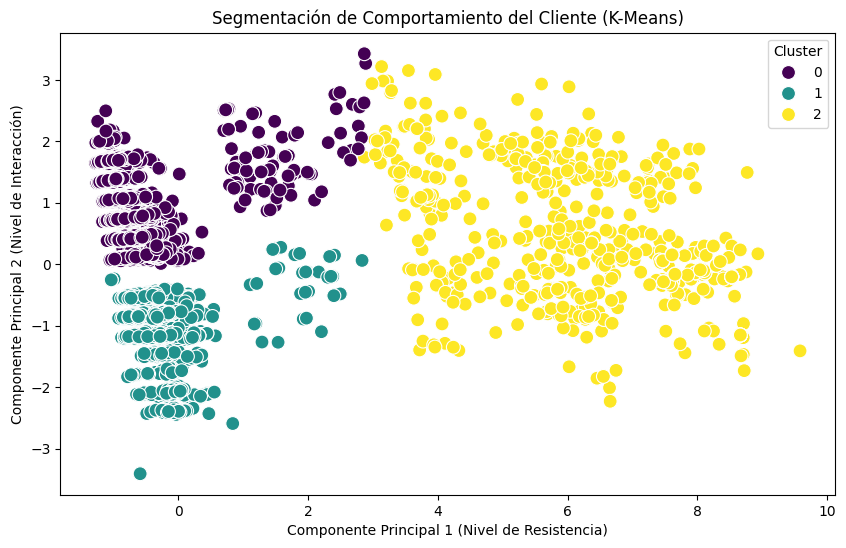

In [26]:
df = pd.read_csv(datos_conv)

# Limpiar datos (Eliminar errores de análisis del LLM)
df_clean = df[df['resultado_conversacion'] != 'FALLO_ANALISIS'].copy()

features_cliente = [
    'sentimiento_promedio_cliente', 
    'tasa_objecion_cliente', 
    'tasa_preguntas_relevantes_cliente', 
    'tasa_palabras_dudosas_cliente', 
    'frecuencia_preocupacion_principal_cliente'
]

X = df_clean[features_cliente]

# 3. Estandarización de los datos (Crucial para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar K-Means (Buscamos 3 clusters de comportamiento)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster_cliente'] = kmeans.fit_predict(X_scaled)

# Asignar nombres descriptivos a los clusters basados en sus centroides
# (Esto se ajusta tras observar los promedios de cada cluster)
cluster_means = df_clean.groupby('cluster_cliente')[features_cliente].mean()

# 5. Visualización de los Clusters usando PCA (Reducción a 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='cluster_cliente', palette='viridis', s=100)
plt.title('Segmentación de Comportamiento del Cliente (K-Means)')
plt.xlabel('Componente Principal 1 (Nivel de Resistencia)')
plt.ylabel('Componente Principal 2 (Nivel de Interacción)')
plt.legend(title='Cluster')
plt.show()

# Guardar el dataset con los clusters
df_clean.to_csv(cluster_datos, index=False)

## 2. Script 2: Matching Óptimo de Técnicas de Venta

### Objetivo
Cruzar los segmentos de clientes descubiertos en el paso anterior con los perfiles de los vendedores para identificar qué técnica maximiza la tasa de conversión (ÉXITO).

### Cómo funciona
1. **Transformación Binaria:** Convierte la columna `resultado_conversacion` en una variable binaria predictiva donde `EXITO = 1` y el resto es `0`.
2. **Cálculo de Tasa de Éxito:** Agrupa los datos por `cluster_cliente` y `vendedor_nombre`, calculando el porcentaje de victorias para cada combinación.
3. **Filtro de Relevancia:** Descarta combinaciones con muy pocas interacciones para evitar sesgos estadísticos.
4. **Recomendación Algorítmica:** Identifica automáticamente mediante programación qué vendedor tiene el mayor porcentaje de éxito en cada uno de los 3 clusters de comportamiento.

### Salida esperada
* Salida en consola de la **Técnica Óptima** recomendada para el Cluster 0, Cluster 1 y Cluster 2.
* Un mapa de calor (`matching_tecnicas_heatmap.png`) que muestra visualmente dónde fracasan y dónde brillan las diferentes técnicas según el estado del cliente.

=== MATCHING ÓPTIMO DE TÉCNICAS POR CLUSTER ===
    cluster_cliente      vendedor_nombre  tasa_exito
5                 0  Vendedor Consultivo    0.572581
25                1  Vendedor Consultivo    0.200935
53                2  Vendedor Relacional    0.357143


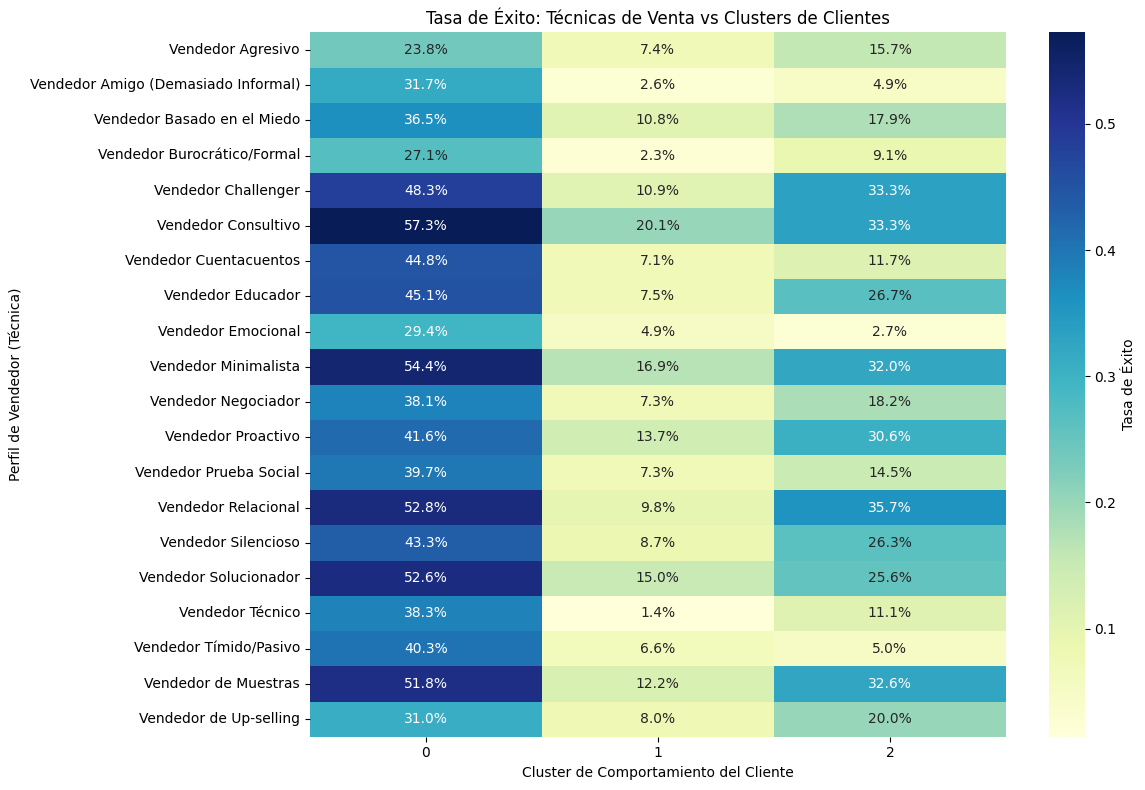

In [ ]:
# Cargar el dataset con los clusters generados en el Script 1
df = pd.read_csv(cluster_datos)

# 1. Definir qué es el Éxito (1 = EXITO, 0 = FALLO)
df['es_exito'] = (df['resultado_conversacion'] == 'EXITO').astype(int)

# 2. Análisis de Rendimiento de Técnicas por Cluster
# Agrupamos por Cluster y Vendedor, y calculamos la tasa de éxito
matching_df = df.groupby(['cluster_cliente', 'vendedor_nombre']).agg(
    total_interacciones=('id_conversacion', 'count'),
    tasa_exito=('es_exito', 'mean')
).reset_index()

# Filtrar solo combinaciones con suficientes datos (ej. mínimo 3 interacciones)
matching_df = matching_df[matching_df['total_interacciones'] >= 3]

# Encontrar la técnica óptima para cada cluster
idx_optimo = matching_df.groupby('cluster_cliente')['tasa_exito'].idxmax()
tecnicas_optimas = matching_df.loc[idx_optimo]

print("=== MATCHING ÓPTIMO DE TÉCNICAS POR CLUSTER ===")
print(tecnicas_optimas[['cluster_cliente', 'vendedor_nombre', 'tasa_exito']])

# 3. Visualización del Matching (Mapa de Calor de Tasa de Éxito)
pivot_matching = matching_df.pivot(index='vendedor_nombre', columns='cluster_cliente', values='tasa_exito').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_matching, annot=True, cmap='YlGnBu', fmt=".1%", cbar_kws={'label': 'Tasa de Éxito'})
plt.title('Tasa de Éxito: Técnicas de Venta vs Clusters de Clientes')
plt.xlabel('Cluster de Comportamiento del Cliente')
plt.ylabel('Perfil de Vendedor (Técnica)')
plt.tight_layout()
plt.show()

## 3. Script 3: Extracción de Reglas (Árbol de Decisión)

### Objetivo
Entrenar un modelo de clasificación supervisada para entender *el porqué* de los éxitos y extraer las "Reglas de Oro" que un equipo comercial humano pueda interpretar y aplicar.

### Cómo funciona
1. **División del Dataset:** Separa los datos en un conjunto de entrenamiento (80%) y prueba (20%) usando `train_test_split`.
2. **Entrenamiento del Modelo:** Entrena un algoritmo `DecisionTreeClassifier`. Se restringe la profundidad máxima (`max_depth=3`) deliberadamente para evitar el sobreajuste (*overfitting*) y garantizar que el árbol resultante sea fácil de leer por un humano.
3. **Evaluación:** Mide la precisión del modelo prediciendo resultados sobre datos que nunca ha visto antes.
4. **Importancia de Features (Feature Importance):** Calcula matemáticamente qué métrica de la interacción (ej. hacer menos preguntas, polaridad más alta, tasa de objeciones) tiene el mayor peso a la hora de predecir un cierre.

### Salida esperada
* Un ranking impreso en consola con la importancia porcentual de cada variable en el cierre de la venta.


Precisión del modelo en Test: 0.67


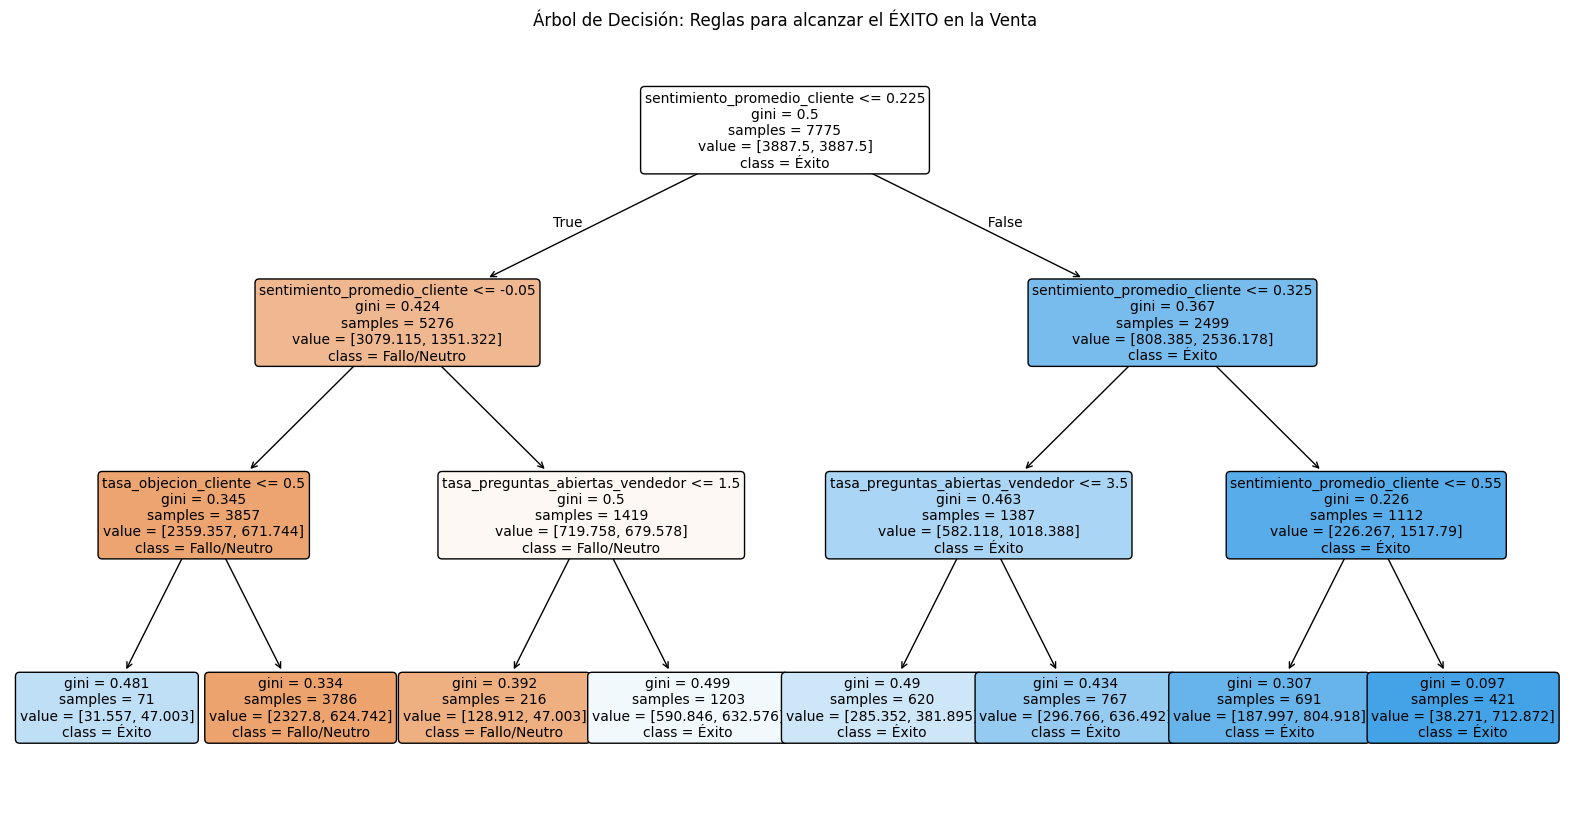


=== IMPORTANCIA DE FEATURES PARA CERRAR LA VENTA ===
sentimiento_promedio_cliente        0.952178
tasa_preguntas_abiertas_vendedor    0.026548
tasa_objecion_cliente               0.021274
polaridad_sentimiento_vendedor      0.000000
dtype: float64


In [28]:
# Cargar datos
df = pd.read_csv(datos_conv)
df = df[df['resultado_conversacion'] != 'FALLO_ANALISIS']

# 1. Preparar Variables (X) y Etiqueta (y)
# Seleccionamos las features de la interacción
X = df[[
    'tasa_objecion_cliente', 
    'tasa_preguntas_abiertas_vendedor', 
    'sentimiento_promedio_cliente',
    'polaridad_sentimiento_vendedor'
]]

# Predecir si es EXITO (1) o no (0)
y = (df['resultado_conversacion'] == 'EXITO').astype(int)

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenar Árbol de Decisión (profundidad baja para interpretar las reglas fácilmente)
clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# 4. Evaluar Precisión (Accuracy)
print(f"Precisión del modelo en Test: {clf.score(X_test, y_test):.2f}")

# 5. Visualizar las Reglas de Venta Extraídas
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Fallo/Neutro', 'Éxito'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Árbol de Decisión: Reglas para alcanzar el ÉXITO en la Venta')
plt.show()

# 6. Importancia de las variables (¿Qué métrica define más el cierre?)
importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== IMPORTANCIA DE FEATURES PARA CERRAR LA VENTA ===")
print(importancias)